In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVR, SVR
from sklearn.linear_model import LinearRegression

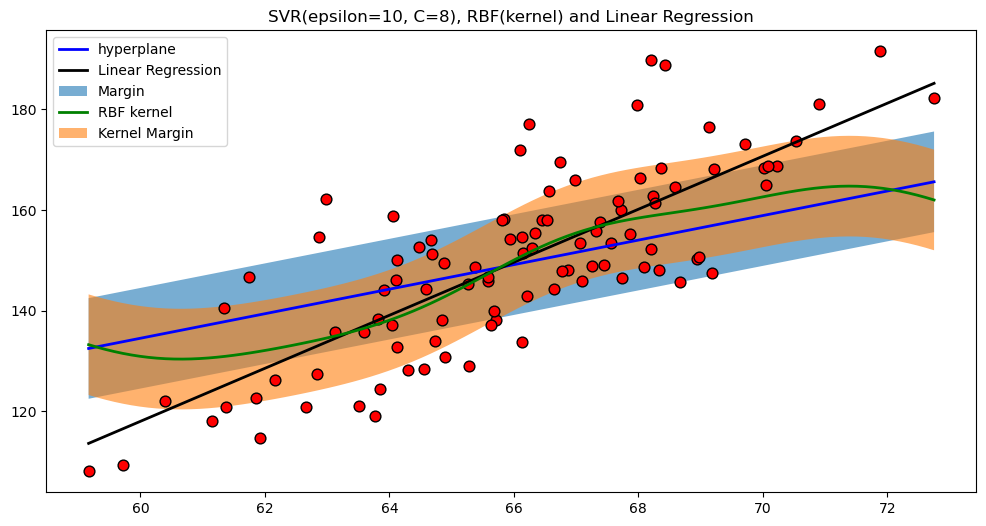

In [108]:
np.random.seed(26)
X = np.random.multivariate_normal(mean=[66, 150], cov=[[9, 50], [50, 400]], size=100)

model = LinearSVR(epsilon=10, tol=0.01, C=8, max_iter=100000)
model.fit(X[:, 0].reshape(-1, 1), X[:, 1]) 

model_2 = LinearRegression()
model_2.fit(X[:, 0].reshape(-1, 1), X[:, 1])

model_3 = SVR(kernel='rbf', gamma='scale', C=5, epsilon=10)
model_3.fit(X[:, 0].reshape(-1, 1), X[:, 1])

x = np.linspace(X[:, 0].min(), X[:, 0].max(), 100).reshape(-1, 1)
y_pred = model.predict(x)
y_pred_2 = model_2.predict(x)
y_pred_3 = model_3.predict(x)


plt.figure(figsize=(12, 6))
plt.plot(x, y_pred, color='blue', linewidth=2, label='hyperplane')
plt.plot(x, y_pred_2, color='black', linewidth=2, label='Linear Regression')
plt.fill_between(x.flatten(), y_pred + model.epsilon, y_pred - model.epsilon, label='Margin', alpha=0.6)
plt.plot(x, y_pred_3, color='green', linewidth=2, label='RBF kernel')
plt.fill_between(x.flatten(), y_pred_3 + model_3.epsilon, y_pred_3 - model_3.epsilon, label='Kernel Margin', alpha=0.6)
plt.legend()
plt.title('SVR(epsilon=10, C=8), RBF(kernel) and Linear Regression')
plt.scatter(X[:, 0], X[:, 1], color='red', edgecolor='k', s=60)
plt.show()


epsilon controls the width f(x) +- epsilon controls the error, and the C controls the penalty to the error term that falls outside the margin increasing C adds more penalty to the errors the outliers have more error so more penatly , so increasing C makes the model to capture towards the outliers, SVR tries to the find the best hyperplane that contains max points inside the margin

Minimizes errors while keeping the line flat (low complexity). It does NOT maximize the margin.

In [73]:
model.predict([[60]]), model_2.predict([[60]])

(array([134.52484246]), array([118.01319533]))

In [109]:
model_3.support_vectors_.shape

(43, 1)